# Liver Cancer Gene Expression Analysis
**Team 3: Sai Karthik, Makayla Phillips, Shreya Krishnan**

**Research Question:** *What genes play the most important role in determining risk of hepatic cancer, and how can expression levels of these genes be used to inform diagnosis of liver cancer?*

Dataset: GSE263786

## 1. Read in Data and Understand Data Structure

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("BME 357 Project Data")

# Expression matrix is not in the local data folder; still pull from GEO
expr_url = "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE263786&format=file&file=GSE263786%5FHTSeq%5Fall%2Etxt%2Egz"
df = pd.read_csv(expr_url, sep="\t", compression="gzip", comment="!", index_col=0)
print("Expression matrix shape:", df.shape)

# Metadata: local CSV (Sample, Description). Disease state derived from Description.
meta_raw = pd.read_csv(DATA_DIR / "metadata_gse263786.csv")
meta_raw["disease_state"] = np.where(
    meta_raw["Description"].str.contains("Normal Liver", case=False, na=False),
    "Normal", "Disease",
)
meta_df = meta_raw.set_index("Sample")[["disease_state"]].reindex(df.columns)

print("\nDisease distribution:")
print(meta_df["disease_state"].value_counts(dropna=False))
print("\nFinal shapes:")
print("Expression:", df.shape)
print("Metadata:", meta_df.shape)


## 2. Data Preprocessing
Inspect missingness, apply mean imputation, standard scaling, PCA feature selection, correlation matrix, and histograms of top correlated features.

Missing values per gene (top 10):
Series([], dtype: int64)

Total genes with missing values: 0
Total samples with missing values: 0


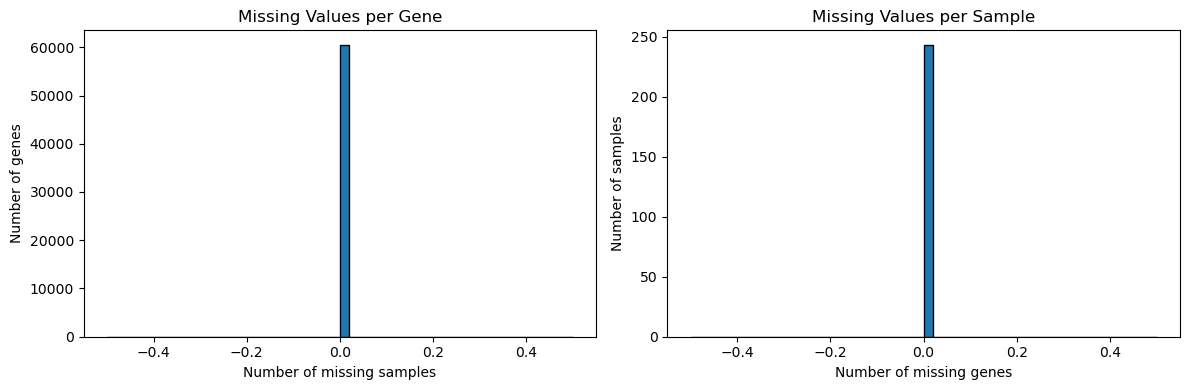

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- Inspect missingness ---
missing_per_gene = df.isnull().sum(axis=1)
missing_per_sample = df.isnull().sum(axis=0)
print("Missing values per gene (top 10):")
print(missing_per_gene[missing_per_gene > 0].sort_values(ascending=False).head(10))
print(f"\nTotal genes with missing values: {(missing_per_gene > 0).sum()}")
print(f"Total samples with missing values: {(missing_per_sample > 0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(missing_per_gene, bins=50, edgecolor='black')
axes[0].set_title('Missing Values per Gene')
axes[0].set_xlabel('Number of missing samples')
axes[0].set_ylabel('Number of genes')
axes[1].hist(missing_per_sample, bins=50, edgecolor='black')
axes[1].set_title('Missing Values per Sample')
axes[1].set_xlabel('Number of missing genes')
axes[1].set_ylabel('Number of samples')
plt.tight_layout()
plt.show()

In [14]:
# --- Mean imputation ---
df_imputed = df.fillna(df.mean(axis=1).to_dict())
df_imputed = df_imputed.fillna(0)  # any all-NaN rows
print(f"Remaining missing values after imputation: {df_imputed.isnull().sum().sum()}")

# --- Filter low-expression genes ---
min_counts, min_samples = 10, 10
gene_mask = (df_imputed > min_counts).sum(axis=1) >= min_samples
df_filtered = df_imputed.loc[gene_mask]
print(f"Genes after filtering (>{min_counts} counts in >={min_samples} samples): {df_filtered.shape[0]}")

# --- Standard scaling ---
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")

Remaining missing values after imputation: 0
Genes after filtering (>10 counts in >=10 samples): 21780
Scaled data shape: (21780, 243)


In [15]:
from pybiomart import Server

# --- Convert Ensembl IDs to Gene Symbols via BioMart ---
# Strip version suffixes (e.g., ENSG00000000003.13 -> ENSG00000000003)
ensembl_ids_versioned = df_filtered.index.tolist()
ensembl_ids_stripped = [eid.split('.')[0] for eid in ensembl_ids_versioned]

# Query Ensembl BioMart
server = Server(host='http://www.ensembl.org')
dataset = server.marts['ENSEMBL_MART_ENSEMBL'].datasets['hsapiens_gene_ensembl']
result = dataset.query(attributes=['ensembl_gene_id', 'hgnc_symbol'])
result.columns = ['ensembl_gene_id', 'hgnc_symbol']

# Build mapping dict
mapping = result[result['hgnc_symbol'].str.len() > 0].drop_duplicates('ensembl_gene_id')
mapping_dict = dict(zip(mapping['ensembl_gene_id'], mapping['hgnc_symbol']))

# Map versioned IDs to symbols
new_index = []
for eid_versioned, eid_stripped in zip(ensembl_ids_versioned, ensembl_ids_stripped):
    symbol = mapping_dict.get(eid_stripped, None)
    new_index.append(symbol if symbol else eid_versioned)

# Handle duplicate gene symbols (keep the one with highest mean expression)
temp_df = df_filtered.copy()
temp_df['symbol'] = new_index
temp_df['mean_expr'] = temp_df.drop(columns=['symbol']).mean(axis=1)
temp_df = temp_df.sort_values('mean_expr', ascending=False)
temp_df = temp_df[~temp_df['symbol'].duplicated(keep='first')]
temp_df = temp_df.drop(columns=['mean_expr'])
temp_df = temp_df.set_index('symbol')

df_filtered = temp_df
print(f"Genes after Ensembl-to-symbol conversion: {df_filtered.shape[0]}")
print(f"Genes with HGNC symbols: {sum(1 for g in df_filtered.index if not g.startswith('ENSG'))}")
print(f"Sample gene names: {df_filtered.index[:10].tolist()}")

# Re-apply standard scaling with new index
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_filtered.T).T,
    index=df_filtered.index,
    columns=df_filtered.columns
)
print(f"Scaled data shape: {df_scaled.shape}")

Genes after Ensembl-to-symbol conversion: 21779
Genes with HGNC symbols: 19407
Sample gene names: ['__alignment_not_unique', 'ALB', '__no_feature', '__ambiguous', 'MT-CO1', 'MT-ND4', 'MT-CO3', '__too_low_aQual', 'SERPINA1', 'HP']
Scaled data shape: (21779, 243)


In [16]:
# --- PCA for feature selection ---
from sklearn.decomposition import PCA

X = df_scaled.T.values  # samples x genes
pca_full = PCA()
pca_full.fit(X)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Number of PCs to retain 90% variance: {n_components_90}")

# Identify top contributing genes from PCA loadings
pca_fit = PCA(n_components=n_components_90)
X_pca = pca_fit.fit_transform(X)

# Gene importance = sum of absolute loadings across retained PCs
loadings = np.abs(pca_fit.components_)  # (n_components x n_genes)
gene_importance = loadings.sum(axis=0)
gene_importance_df = pd.DataFrame({
    'gene': df_scaled.index,
    'pca_importance': gene_importance
}).sort_values('pca_importance', ascending=False)

# Select top genes by PCA importance
n_top_genes = 2000
top_pca_genes = gene_importance_df.head(n_top_genes)['gene'].tolist()
df_selected = df_scaled.loc[top_pca_genes]
print(f"Genes selected via PCA feature selection: {df_selected.shape[0]}")

Number of PCs to retain 90% variance: 67
Genes selected via PCA feature selection: 2000


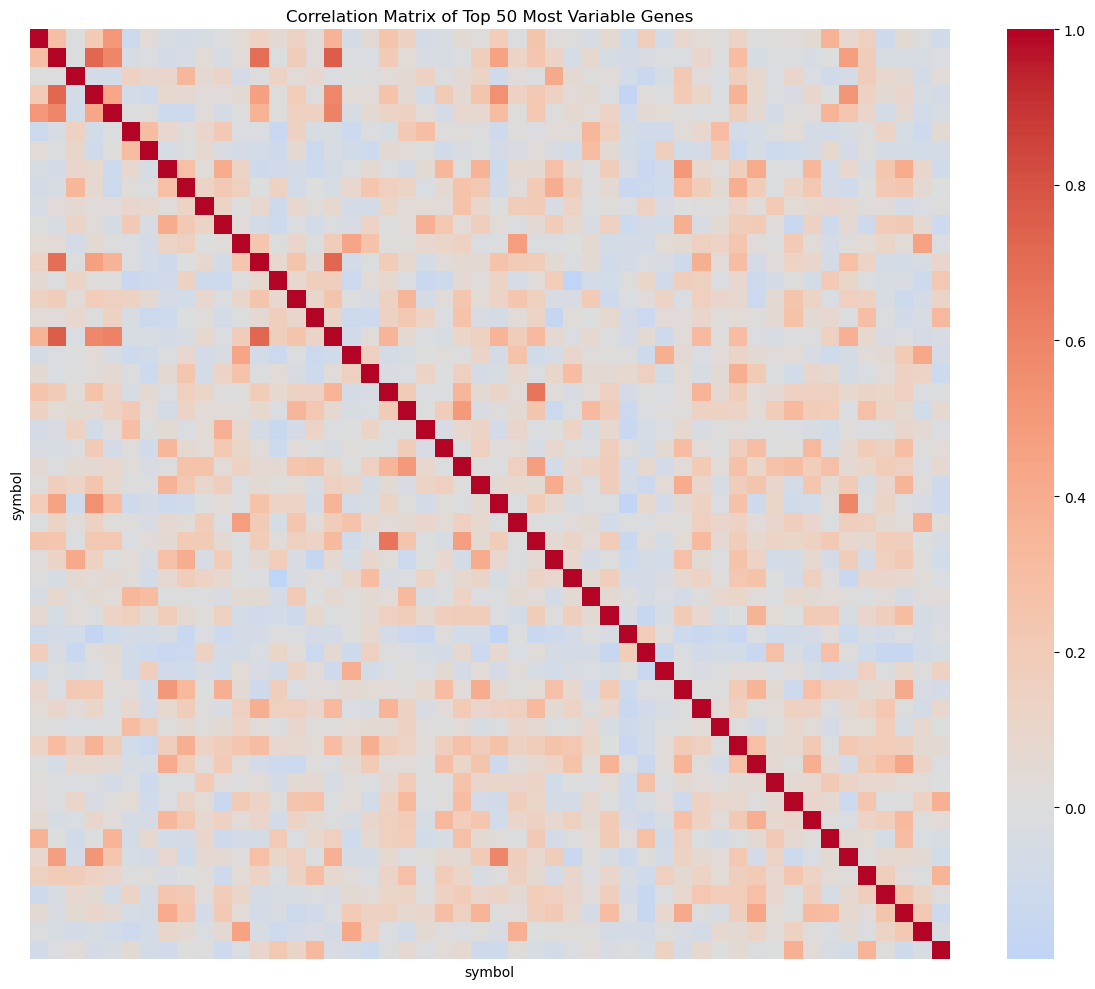

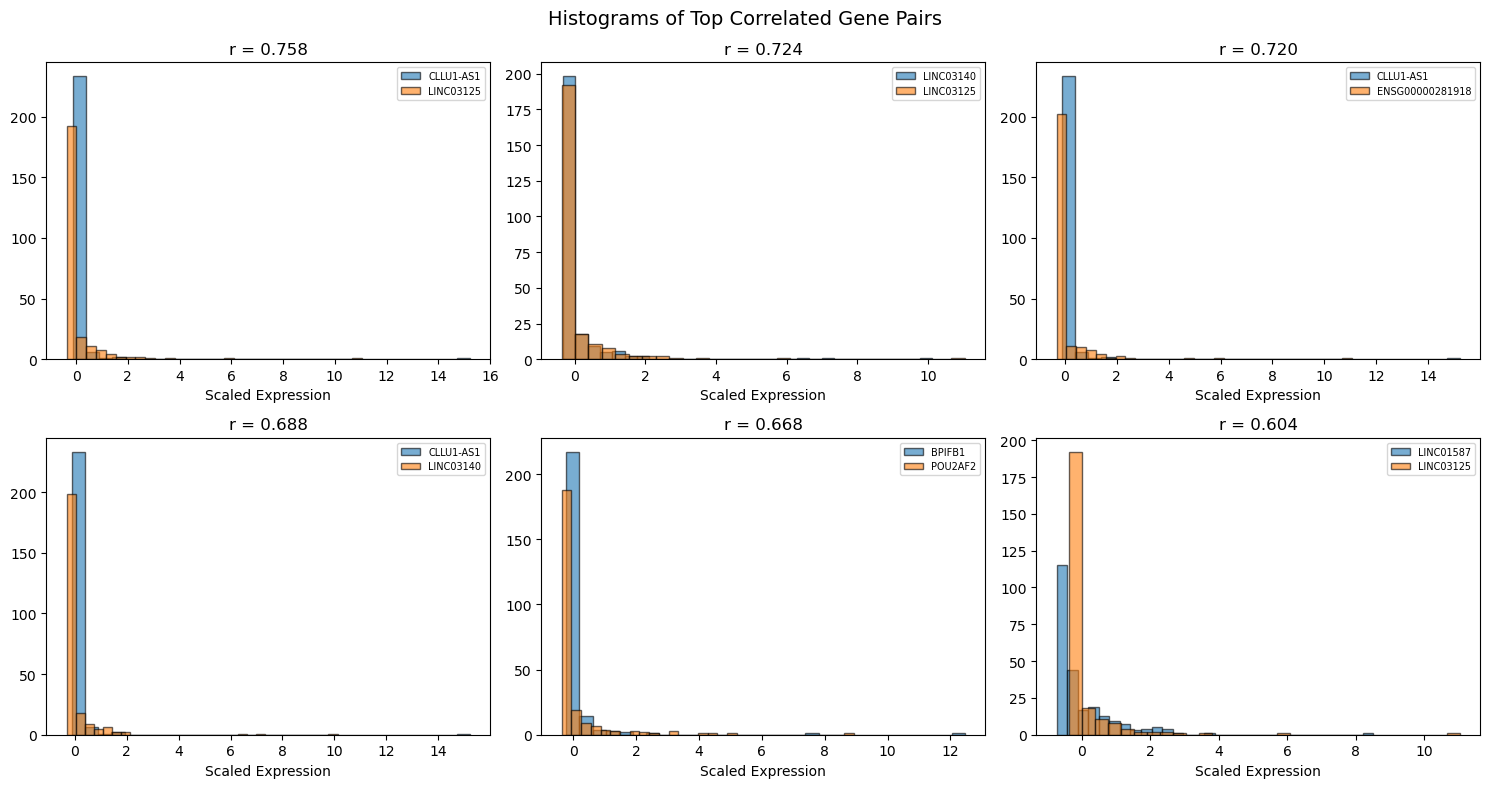

In [17]:
# --- Correlation matrix of top 50 most variable selected genes ---
gene_variance = df_selected.var(axis=1).sort_values(ascending=False)
top_var_genes = gene_variance.head(50).index
corr_matrix = df_selected.loc[top_var_genes].T.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title('Correlation Matrix of Top 50 Most Variable Genes')
plt.tight_layout()
plt.show()

# --- Histograms of top correlated gene pairs ---
corr_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_pairs = corr_upper.stack().abs().sort_values(ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, ((gene1, gene2), corr_val) in enumerate(top_pairs.items()):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df_selected.loc[gene1], bins=30, alpha=0.6, label=gene1[:15], edgecolor='black')
    ax.hist(df_selected.loc[gene2], bins=30, alpha=0.6, label=gene2[:15], edgecolor='black')
    ax.set_title(f'r = {corr_val:.3f}')
    ax.legend(fontsize=7)
    ax.set_xlabel('Scaled Expression')
plt.suptitle('Histograms of Top Correlated Gene Pairs', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Unsupervised Learning
PCA to reduce dimensionality (retaining 90% variance), scatter plot visualization, K-means clustering of genes with elbow method.

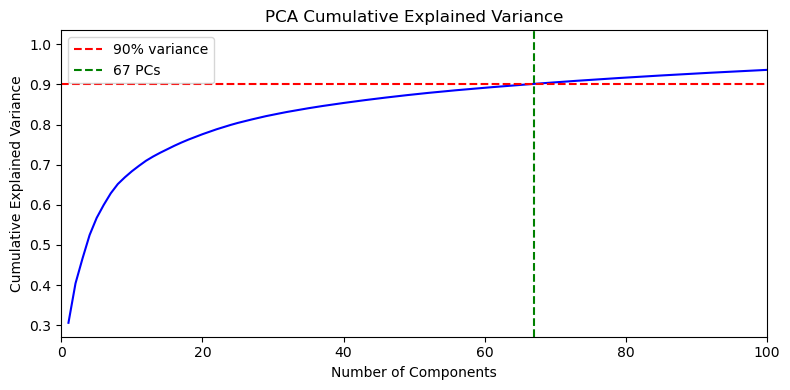

PCA-reduced data shape: (243, 67)


In [18]:
# --- PCA visualization (already computed above) ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axvline(x=n_components_90, color='g', linestyle='--', label=f'{n_components_90} PCs')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.legend()
plt.xlim(0, min(100, len(cumulative_var)))
plt.tight_layout()
plt.show()

print(f"PCA-reduced data shape: {X_pca.shape}")

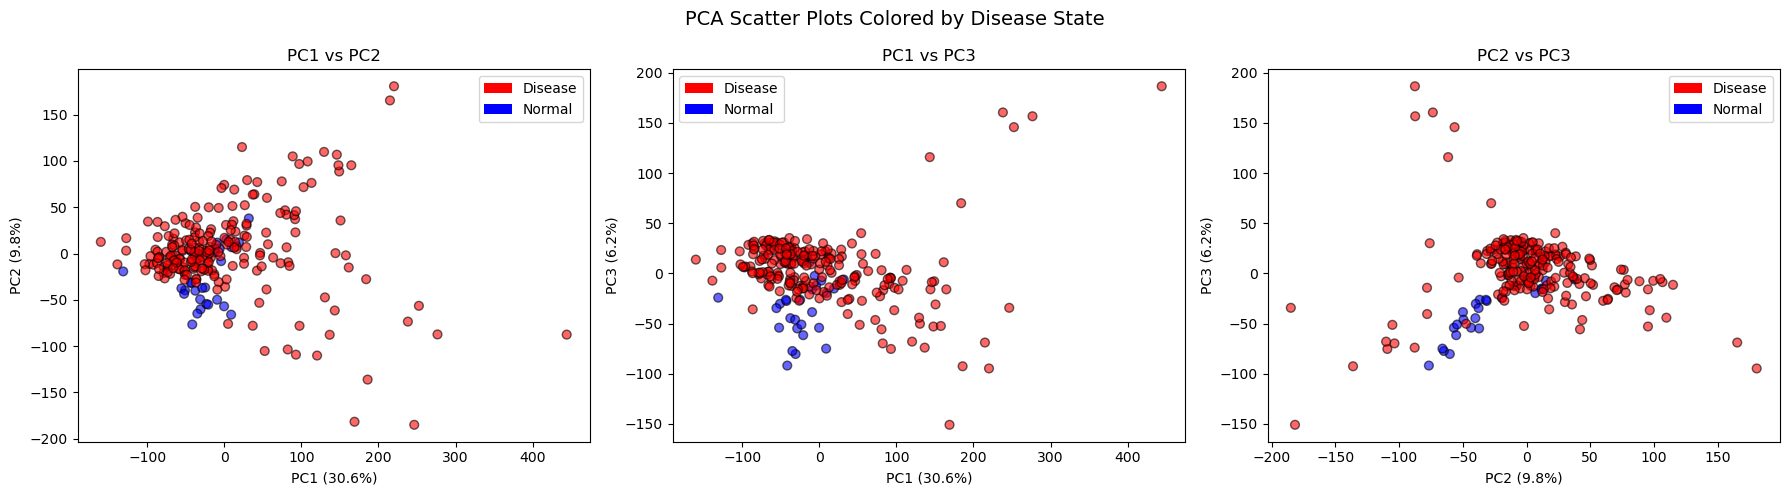

In [19]:
# --- PCA scatter plots colored by disease state ---
from matplotlib.patches import Patch

labels = meta_df.loc[df_scaled.columns, 'disease_state'].values
colors = ['red' if l == 'Disease' else 'blue' for l in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[0].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].set_title('PC1 vs PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[1].set_xlabel(f'PC1 ({pca_fit.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[1].set_title('PC1 vs PC3')

axes[2].scatter(X_pca[:, 1], X_pca[:, 2], c=colors, alpha=0.6, edgecolors='k', s=40)
axes[2].set_xlabel(f'PC2 ({pca_fit.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_ylabel(f'PC3 ({pca_fit.explained_variance_ratio_[2]*100:.1f}%)')
axes[2].set_title('PC2 vs PC3')

legend_elements = [Patch(facecolor='red', label='Disease'), Patch(facecolor='blue', label='Normal')]
for ax in axes:
    ax.legend(handles=legend_elements)
plt.suptitle('PCA Scatter Plots Colored by Disease State', fontsize=14)
plt.tight_layout()
plt.show()

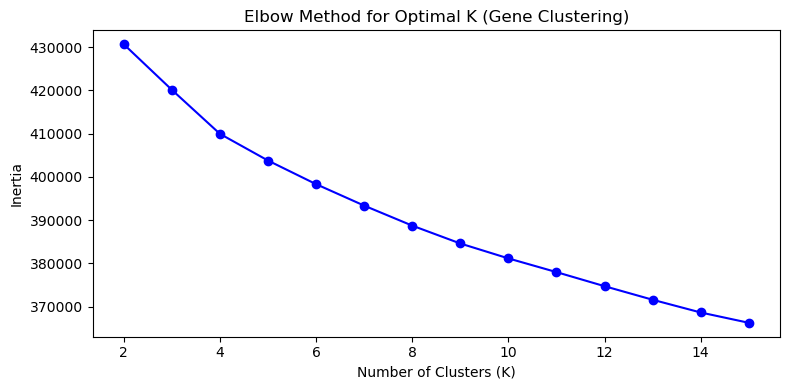

Optimal K selected: 5


In [20]:
from sklearn.cluster import KMeans

# --- K-means clustering of GENES based on expression profiles ---
# Genes as rows, samples as features
X_genes = df_selected.values  # (n_genes x n_samples)

# Elbow method
inertias = []
K_range = range(2, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_genes)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (Gene Clustering)')
plt.tight_layout()
plt.show()

# Select optimal K via maximum second derivative
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
optimal_k = list(K_range)[np.argmax(diffs2) + 2]
print(f"Optimal K selected: {optimal_k}")

Gene cluster sizes:
cluster
0    611
1    557
2    207
3    443
4    182
Name: count, dtype: int64


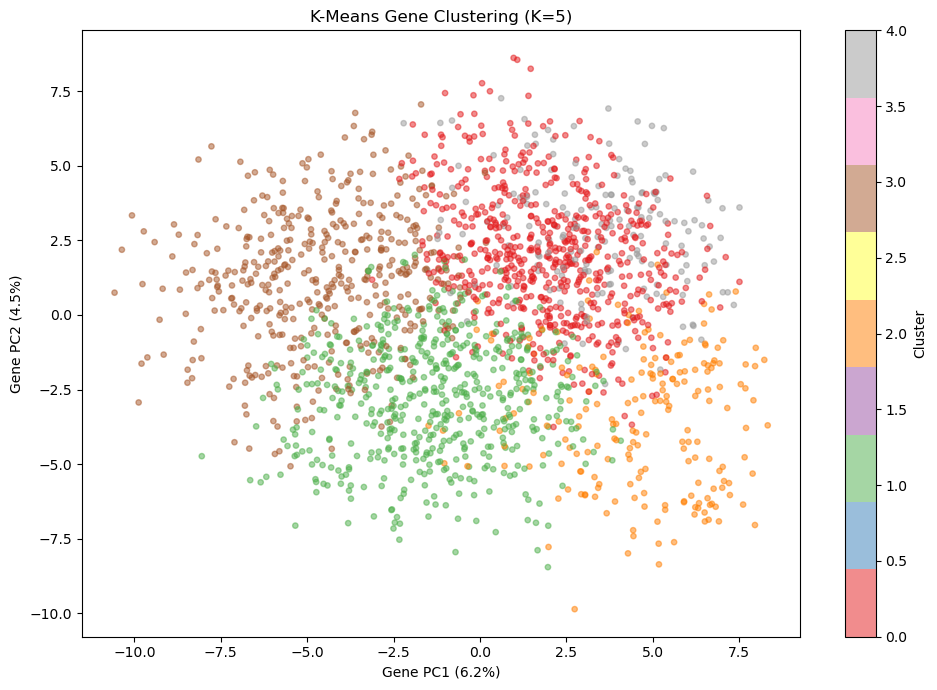

In [21]:
# --- Apply K-means to cluster genes ---
kmeans_genes = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
gene_cluster_labels = kmeans_genes.fit_predict(X_genes)

gene_clusters = pd.DataFrame({
    'gene': df_selected.index,
    'cluster': gene_cluster_labels
})

print("Gene cluster sizes:")
print(gene_clusters['cluster'].value_counts().sort_index())

# Visualize gene clusters using PCA on genes
pca_gene_viz = PCA(n_components=2)
X_genes_2d = pca_gene_viz.fit_transform(X_genes)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_genes_2d[:, 0], X_genes_2d[:, 1],
                      c=gene_cluster_labels, cmap='Set1', alpha=0.5, s=15)
plt.xlabel(f'Gene PC1 ({pca_gene_viz.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Gene PC2 ({pca_gene_viz.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'K-Means Gene Clustering (K={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

## 4. Network Construction

### 4a. PPI Network from prebuilt adjacency (BME 357 Project Data/M_PPI.npz)

In [ ]:
import networkx as nx
from scipy import sparse

# --- Load prebuilt PPI network ---
M_PPI = sparse.load_npz(DATA_DIR / "M_PPI.npz").tocsr()
ppi_name_arr = np.load(DATA_DIR / "PPI_name.npy", allow_pickle=True).squeeze()
ppi_names = np.array([str(np.asarray(n).item()) for n in ppi_name_arr])
ppi_idx = {g: i for i, g in enumerate(ppi_names)}

# Restrict to PCA-selected genes that exist in the PPI database
query_genes = df_selected.index.tolist()
ppi_genes_sel = [g for g in query_genes if g in ppi_idx]
print(f"PCA-selected genes mappable to PPI: {len(ppi_genes_sel)} / {len(query_genes)}")

ppi_pos = np.array([ppi_idx[g] for g in ppi_genes_sel])
M_PPI_sub = M_PPI[ppi_pos][:, ppi_pos].astype(np.uint8)
M_PPI_sub = M_PPI_sub.maximum(M_PPI_sub.T)  # treat as undirected
M_PPI_sub.setdiag(0)
M_PPI_sub.eliminate_zeros()

ppi_graph = nx.from_scipy_sparse_array(M_PPI_sub, edge_attribute="weight")
ppi_graph = nx.relabel_nodes(ppi_graph, {i: ppi_genes_sel[i] for i in range(len(ppi_genes_sel))})
ppi_graph.remove_nodes_from(list(nx.isolates(ppi_graph)))
print(f"PPI Network: {ppi_graph.number_of_nodes()} nodes, {ppi_graph.number_of_edges()} edges")

# PPI degree
ppi_degrees = dict(ppi_graph.degree())
ppi_degree_df = (
    pd.DataFrame(list(ppi_degrees.items()), columns=["gene", "ppi_degree"])
      .sort_values("ppi_degree", ascending=False)
)
print("\nTop 20 PPI hub genes:")
print(ppi_degree_df.head(20).to_string(index=False))


In [ ]:
# --- Visualize PPI Network ---
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(ppi_graph, k=0.3, seed=42)

node_sizes = [ppi_degrees.get(n, 1) * 5 + 20 for n in ppi_graph.nodes()]
node_colors = [ppi_degrees.get(n, 0) for n in ppi_graph.nodes()]

nx.draw_networkx_edges(ppi_graph, pos, alpha=0.15)
nodes = nx.draw_networkx_nodes(ppi_graph, pos, node_size=node_sizes,
                                node_color=node_colors, cmap='YlOrRd', alpha=0.8)

top_hubs_ppi = ppi_degree_df.head(15)['gene'].tolist()
hub_labels = {n: n for n in ppi_graph.nodes() if n in top_hubs_ppi}
nx.draw_networkx_labels(ppi_graph, pos, labels=hub_labels, font_size=8, font_weight='bold')

plt.colorbar(nodes, label='Degree')
plt.title('Protein-Protein Interaction Network (prebuilt M_PPI)')
plt.axis('off')
plt.tight_layout()
plt.show()


### 4b. Gene Regulatory Network from prebuilt adjacency (BME 357 Project Data/M_GRN.npz)

In [ ]:
from scipy import stats

# --- Load prebuilt GRN ---
M_GRN = sparse.load_npz(DATA_DIR / "M_GRN.npz").tocsr()
grn_name_arr = np.load(DATA_DIR / "GRN_name.npy", allow_pickle=True).squeeze()
grn_names = np.array([str(np.asarray(n).item()) for n in grn_name_arr])
grn_idx = {g: i for i, g in enumerate(grn_names)}

# Restrict to PCA-selected genes present in the GRN
grn_genes_sel = [g for g in df_selected.index if g in grn_idx]
print(f"PCA-selected genes mappable to GRN: {len(grn_genes_sel)} / {df_selected.shape[0]}")

grn_pos = np.array([grn_idx[g] for g in grn_genes_sel])
M_GRN_sub = M_GRN[grn_pos][:, grn_pos].astype(np.uint8)
M_GRN_sub = M_GRN_sub.maximum(M_GRN_sub.T)  # undirected for module/hub analysis
M_GRN_sub.setdiag(0)
M_GRN_sub.eliminate_zeros()

grn_graph = nx.from_scipy_sparse_array(M_GRN_sub, edge_attribute="weight")
grn_graph = nx.relabel_nodes(grn_graph, {i: grn_genes_sel[i] for i in range(len(grn_genes_sel))})
grn_graph.remove_nodes_from(list(nx.isolates(grn_graph)))
print(f"GRN: {grn_graph.number_of_nodes()} nodes, {grn_graph.number_of_edges()} edges")


In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

# --- Module detection: greedy modularity on the prebuilt GRN ---
if grn_graph.number_of_edges() > 0:
    communities = list(greedy_modularity_communities(grn_graph))
else:
    communities = []

gene_to_module = {}
for mod_id, community in enumerate(communities, start=1):
    for gene in community:
        gene_to_module[gene] = mod_id

module_labels = np.array([gene_to_module.get(g, -1) for g in df_selected.index])
gene_modules = pd.DataFrame({"gene": df_selected.index, "module": module_labels})
n_modules = len(communities)
print(f"GRN modules detected: {n_modules}")

print("\nGenes per module (top 15):")
mod_counts = gene_modules[gene_modules["module"] != -1]["module"].value_counts().sort_index()
print(mod_counts.head(15))
print(f"Genes not in any GRN module: {(gene_modules['module'] == -1).sum()}")


In [ ]:
# --- Module-trait correlation ---
y_binary = (meta_df.loc[df_selected.columns, "disease_state"] == "Disease").astype(int).values

module_trait_corr = {}
for mod in sorted(m for m in gene_modules["module"].unique() if m != -1):
    mod_genes = gene_modules[gene_modules["module"] == mod]["gene"].values
    if len(mod_genes) < 2:
        continue
    mod_expr = df_selected.loc[mod_genes].T.values
    me = PCA(n_components=1).fit_transform(mod_expr).flatten()
    r, p = stats.pearsonr(me, y_binary)
    module_trait_corr[mod] = (r, p)

print("Module-Disease Trait Correlations (top 20 by |r|):")
print(f"{'Module':<10} {'Correlation':>12} {'p-value':>12} {'Genes':>8}")
ranked = sorted(module_trait_corr.items(), key=lambda x: abs(x[1][0]), reverse=True)
for mod, (r, p) in ranked[:20]:
    n_genes = (gene_modules["module"] == mod).sum()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    print(f"  {mod:<8} {r:>12.4f} {p:>12.2e} {n_genes:>8} {sig}")

sig_modules = [mod for mod, (r, p) in module_trait_corr.items() if p < 0.05]
print(f"\nDisease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")


In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# --- Compare K-Means Clusters vs GRN Modules ---
kmeans_labels = gene_clusters.set_index('gene')['cluster']
grn_module_labels = gene_modules.set_index('gene')['module']

shared_genes = kmeans_labels.index.intersection(grn_module_labels.index)
km_aligned = kmeans_labels.loc[shared_genes].values
gm_aligned = grn_module_labels.loc[shared_genes].values

ari = adjusted_rand_score(km_aligned, gm_aligned)
nmi = normalized_mutual_info_score(km_aligned, gm_aligned)
print(f"K-Means vs GRN Module Agreement ({len(shared_genes)} genes):")
print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
print(f"  Normalized Mutual Information (NMI): {nmi:.4f}")

contingency = pd.crosstab(
    pd.Series(km_aligned, name='K-Means Cluster'),
    pd.Series(gm_aligned, name='GRN Module')
)

plt.figure(figsize=(12, 6))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlOrRd')
plt.title(f'K-Means Clusters vs GRN Modules (ARI={ari:.3f}, NMI={nmi:.3f})')
plt.xlabel('GRN Module')
plt.ylabel('K-Means Cluster')
plt.tight_layout()
plt.show()

# Disease-trait correlation per K-means cluster
kmeans_trait_corr = {}
for cl in sorted(gene_clusters['cluster'].unique()):
    cl_genes = gene_clusters[gene_clusters['cluster'] == cl]['gene'].values
    cl_genes_in_data = [g for g in cl_genes if g in df_selected.index]
    if len(cl_genes_in_data) < 2:
        continue
    cl_expr = df_selected.loc[cl_genes_in_data].T.values
    eigengene = PCA(n_components=1).fit_transform(cl_expr).flatten()
    r, p = stats.pearsonr(eigengene, y_binary)
    kmeans_trait_corr[cl] = (r, p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grn_mods = sorted(module_trait_corr.keys())
grn_rs = [module_trait_corr[m][0] for m in grn_mods]
grn_ps = [module_trait_corr[m][1] for m in grn_mods]
colors_g = ['red' if p < 0.05 else 'gray' for p in grn_ps]
axes[0].bar(range(len(grn_mods)), grn_rs, color=colors_g, edgecolor='black')
axes[0].set_xticks(range(len(grn_mods)))
axes[0].set_xticklabels([f'M{m}' for m in grn_mods], fontsize=8, rotation=90)
axes[0].set_xlabel('GRN Module')
axes[0].set_ylabel('Pearson r (vs Disease)')
axes[0].set_title('GRN Module-Disease Correlations')
axes[0].axhline(0, color='black', linewidth=0.5)

km_cls = sorted(kmeans_trait_corr.keys())
km_rs = [kmeans_trait_corr[c][0] for c in km_cls]
km_ps = [kmeans_trait_corr[c][1] for c in km_cls]
colors_k = ['red' if p < 0.05 else 'gray' for p in km_ps]
axes[1].bar(range(len(km_cls)), km_rs, color=colors_k, edgecolor='black')
axes[1].set_xticks(range(len(km_cls)))
axes[1].set_xticklabels([f'C{c}' for c in km_cls], fontsize=8)
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Pearson r (vs Disease)')
axes[1].set_title('K-Means Cluster-Disease Correlations')
axes[1].axhline(0, color='black', linewidth=0.5)

plt.suptitle('Clustering Method Comparison: Disease Association', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nGRN disease-significant modules (p<0.05): {len(sig_modules)}/{len(module_trait_corr)}")
km_sig = [c for c, (r, p) in kmeans_trait_corr.items() if p < 0.05]
print(f"K-Means disease-significant clusters (p<0.05): {len(km_sig)}/{len(kmeans_trait_corr)}")


In [ ]:
# --- Visualize GRN ---
plt.figure(figsize=(14, 10))
if grn_graph.number_of_nodes() > 0:
    pos_grn = nx.spring_layout(grn_graph, k=0.5, seed=42)
    grn_degrees = dict(grn_graph.degree())
    node_sizes_grn = [grn_degrees[n] * 3 + 20 for n in grn_graph.nodes()]
    node_colors_grn = [grn_degrees[n] for n in grn_graph.nodes()]

    nx.draw_networkx_edges(grn_graph, pos_grn, alpha=0.1)
    nodes_grn = nx.draw_networkx_nodes(grn_graph, pos_grn, node_size=node_sizes_grn,
                                        node_color=node_colors_grn, cmap='viridis', alpha=0.8)
    grn_degree_df = (
        pd.DataFrame(list(grn_degrees.items()), columns=['gene', 'grn_degree'])
          .sort_values('grn_degree', ascending=False)
    )
    top_hubs_grn = grn_degree_df.head(15)['gene'].tolist()
    hub_labels_grn = {n: n for n in grn_graph.nodes() if n in top_hubs_grn}
    nx.draw_networkx_labels(grn_graph, pos_grn, labels=hub_labels_grn, font_size=8, font_weight='bold')

    plt.colorbar(nodes_grn, label='Degree')
    plt.title('Gene Regulatory Network (prebuilt M_GRN)')
else:
    plt.text(0.5, 0.5, 'GRN is empty for selected genes.', ha='center', va='center', fontsize=14)
    plt.title('Gene Regulatory Network (empty)')
plt.axis('off')
plt.tight_layout()
plt.show()


## 5. Hub Gene Identification
Count connections in GRN and PPI, consolidate into a combined score, apply threshold.

Hub gene threshold (mean + 1 SD): 0.453
Number of hub genes identified: 11

Top 25 Hub Genes:
    gene  ppi_degree  grn_degree  combined_score
   HSPA6         1.0         3.0        1.111111
  DNAJB1         1.0         3.0        1.111111
  HSPA1A         1.0         3.0        1.111111
  HSPA1B         0.0         3.0        1.000000
     LTF         9.0         0.0        1.000000
    MMP9         8.0         0.0        0.888889
     MPO         7.0         0.0        0.777778
    LCN2         6.0         0.0        0.666667
 CEACAM8         5.0         0.0        0.555556
    MMP8         5.0         0.0        0.555556
   PRTN3         5.0         0.0        0.555556
    SPP1         4.0         0.0        0.444444
    AZU1         4.0         0.0        0.444444
   OLFM4         4.0         0.0        0.444444
    CTSK         4.0         0.0        0.444444
PRAMEF10         0.0         1.0        0.333333
    IL1A         3.0         0.0        0.333333
  COL3A1         3.0    

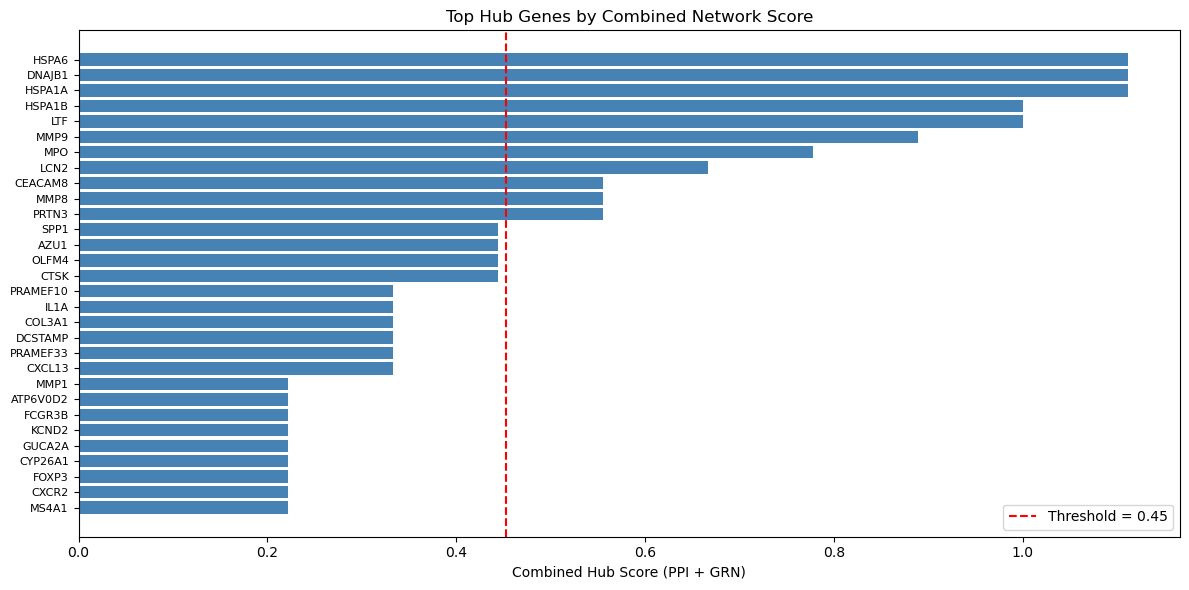

In [28]:
# --- Hub Gene Identification ---
# GRN degrees
if grn_graph.number_of_nodes() > 0:
    grn_degree_all = pd.DataFrame(list(dict(grn_graph.degree()).items()), columns=['gene', 'grn_degree'])
else:
    grn_degree_all = pd.DataFrame(columns=['gene', 'grn_degree'])

# Merge PPI + GRN degrees
hub_scores = pd.merge(ppi_degree_df, grn_degree_all, on='gene', how='outer').fillna(0)

# Normalize each to 0-1 and compute combined score
if hub_scores['ppi_degree'].max() > 0:
    hub_scores['ppi_norm'] = hub_scores['ppi_degree'] / hub_scores['ppi_degree'].max()
else:
    hub_scores['ppi_norm'] = 0
if hub_scores['grn_degree'].max() > 0:
    hub_scores['grn_norm'] = hub_scores['grn_degree'] / hub_scores['grn_degree'].max()
else:
    hub_scores['grn_norm'] = 0

hub_scores['combined_score'] = hub_scores['ppi_norm'] + hub_scores['grn_norm']
hub_scores = hub_scores.sort_values('combined_score', ascending=False)

# Threshold: mean + 1 SD
threshold = hub_scores['combined_score'].mean() + hub_scores['combined_score'].std()
hub_genes = hub_scores[hub_scores['combined_score'] >= threshold]['gene'].tolist()

print(f"Hub gene threshold (mean + 1 SD): {threshold:.3f}")
print(f"Number of hub genes identified: {len(hub_genes)}")
print(f"\nTop 25 Hub Genes:")
print(hub_scores.head(25)[['gene', 'ppi_degree', 'grn_degree', 'combined_score']].to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
top_n = min(30, len(hub_scores))
plt.barh(range(top_n), hub_scores.head(top_n)['combined_score'].values, color='steelblue')
plt.yticks(range(top_n), hub_scores.head(top_n)['gene'].values, fontsize=8)
plt.xlabel('Combined Hub Score (PPI + GRN)')
plt.title('Top Hub Genes by Combined Network Score')
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.2f}')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Final Solution: Classification
Train LDA and Logistic Regression using hub gene expression, select the better model, evaluate with p-values.

In [29]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)

# --- Prepare hub gene feature matrix ---
# Match hub genes to expression data (may be gene symbols from STRING vs Ensembl IDs)
hub_genes_in_data = [g for g in hub_genes if g in df_scaled.index]
print(f"Hub genes found in expression data: {len(hub_genes_in_data)}")

# Fallback: if STRING returned gene symbols, try top hub genes from hub_scores
if len(hub_genes_in_data) < 5:
    hub_genes_in_data = [g for g in hub_scores.head(50)['gene'] if g in df_scaled.index]
    print(f"Hub genes after broadening search: {len(hub_genes_in_data)}")

# Final fallback: use top PCA-important genes that are also high-variance
if len(hub_genes_in_data) < 5:
    print("Using top PCA-selected genes as features...")
    hub_genes_in_data = gene_importance_df.head(30)['gene'].tolist()

X_hub = df_scaled.loc[hub_genes_in_data].T.values
y = (meta_df.loc[df_scaled.columns, 'disease_state'] == 'Disease').astype(int).values
feature_names = hub_genes_in_data

print(f"\nFeature matrix: {X_hub.shape[0]} samples x {X_hub.shape[1]} hub gene features")
print(f"Class distribution: Disease={y.sum()}, Normal={len(y)-y.sum()}")

Hub genes found in expression data: 11

Feature matrix: 243 samples x 11 hub gene features
Class distribution: Disease=216, Normal=27


In [30]:
# --- Train and compare LDA vs Logistic Regression ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lda = LinearDiscriminantAnalysis()
lda_scores = cross_val_score(lda, X_hub, y, cv=cv, scoring='accuracy')

lr = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')
lr_scores = cross_val_score(lr, X_hub, y, cv=cv, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
print(f"  LDA Accuracy:                {lda_scores.mean():.4f} +/- {lda_scores.std():.4f}")
print(f"  Logistic Regression Accuracy: {lr_scores.mean():.4f} +/- {lr_scores.std():.4f}")

# Select the better model
if lda_scores.mean() >= lr_scores.mean():
    best_model_name = "LDA"
    best_model = LinearDiscriminantAnalysis()
else:
    best_model_name = "Logistic Regression"
    best_model = LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced')

print(f"\nSelected model: {best_model_name}")

# Fit on full data
best_model.fit(X_hub, y)
y_pred = best_model.predict(X_hub)

print(f"\n{best_model_name} Full-Data Performance:")
print(classification_report(y, y_pred, target_names=['Normal', 'Disease']))

5-Fold Cross-Validation Results:
  LDA Accuracy:                0.8932 +/- 0.0231
  Logistic Regression Accuracy: 0.9136 +/- 0.0270

Selected model: Logistic Regression

Logistic Regression Full-Data Performance:
              precision    recall  f1-score   support

      Normal       0.65      0.89      0.75        27
     Disease       0.99      0.94      0.96       216

    accuracy                           0.93       243
   macro avg       0.82      0.91      0.86       243
weighted avg       0.95      0.93      0.94       243



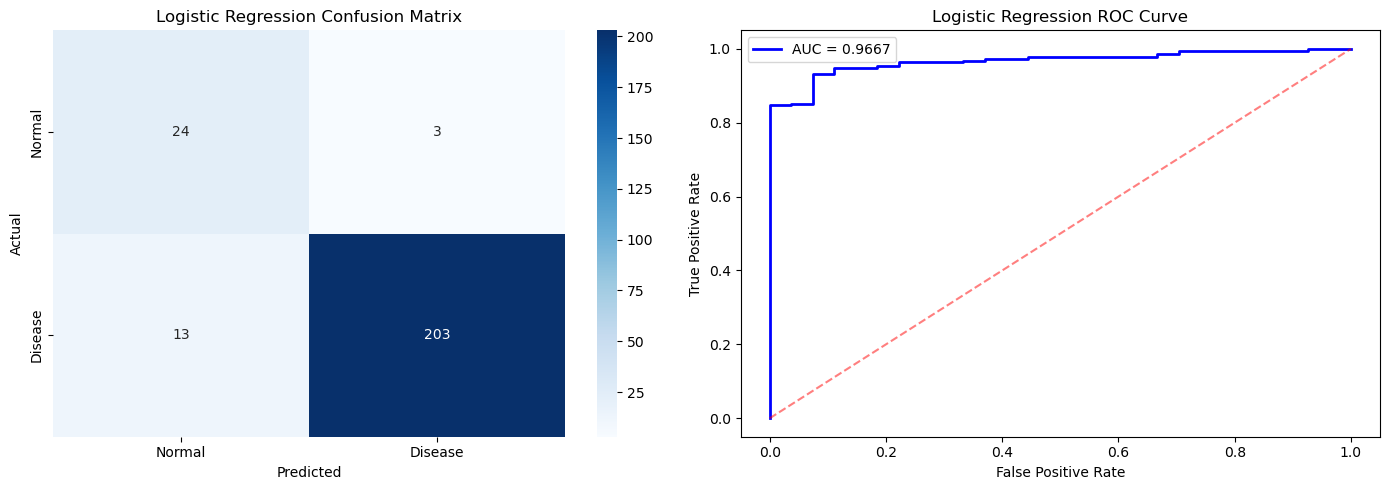

In [31]:
# --- Confusion Matrix and ROC Curve ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Disease'], yticklabels=['Normal', 'Disease'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'{best_model_name} Confusion Matrix')

if hasattr(best_model, 'predict_proba'):
    y_score = best_model.predict_proba(X_hub)[:, 1]
else:
    y_score = best_model.decision_function(X_hub)
fpr, tpr, _ = roc_curve(y, y_score)
auc = roc_auc_score(y, y_score)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{best_model_name} ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# --- Feature p-values, model coefficients, TF/Receptor annotation ---
feature_pvals = []
for i, gene in enumerate(feature_names):
    disease_vals = X_hub[y == 1, i]
    normal_vals = X_hub[y == 0, i]
    _, p = stats.ttest_ind(disease_vals, normal_vals, equal_var=False)
    feature_pvals.append(p)

# Annotate hub-gene features with TF / Receptor membership
tf_set = set(pd.read_csv(DATA_DIR / "TF.csv", header=None).iloc[:, 0].astype(str))
receptor_set = set(pd.read_csv(DATA_DIR / "Receptor.csv", header=None).iloc[:, 0].astype(str))

feature_importance = pd.DataFrame({
    'gene': feature_names,
    'p_value': feature_pvals,
    'neg_log10_p': -np.log10(np.array(feature_pvals).clip(min=1e-300)),
    'is_TF': [g in tf_set for g in feature_names],
    'is_Receptor': [g in receptor_set for g in feature_names],
})

if best_model_name == "Logistic Regression":
    feature_importance['coefficient'] = best_model.coef_[0]
elif best_model_name == "LDA":
    feature_importance['coefficient'] = best_model.scalings_.flatten()[:len(feature_names)]

feature_importance = feature_importance.sort_values('p_value')
feature_importance['significant'] = feature_importance['p_value'] < 0.05

print("Hub Gene Feature Analysis:")
print(f"{'Gene':<14} {'p-value':>12} {'Coefficient':>12} {'Significant':>12} {'TF':>4} {'Receptor':>9}")
print("-" * 70)
for _, row in feature_importance.head(30).iterrows():
    sig = 'Yes' if row['significant'] else 'No'
    coef = f"{row.get('coefficient', 0):.4f}"
    tf_flag = 'Y' if row['is_TF'] else ''
    rec_flag = 'Y' if row['is_Receptor'] else ''
    print(f"{row['gene']:<14} {row['p_value']:>12.2e} {coef:>12} {sig:>12} {tf_flag:>4} {rec_flag:>9}")

print(f"\nSignificant features (p<0.05): {feature_importance['significant'].sum()} / {len(feature_importance)}")
print(f"Hub genes that are TFs: {feature_importance['is_TF'].sum()}")
print(f"Hub genes that are Receptors: {feature_importance['is_Receptor'].sum()}")


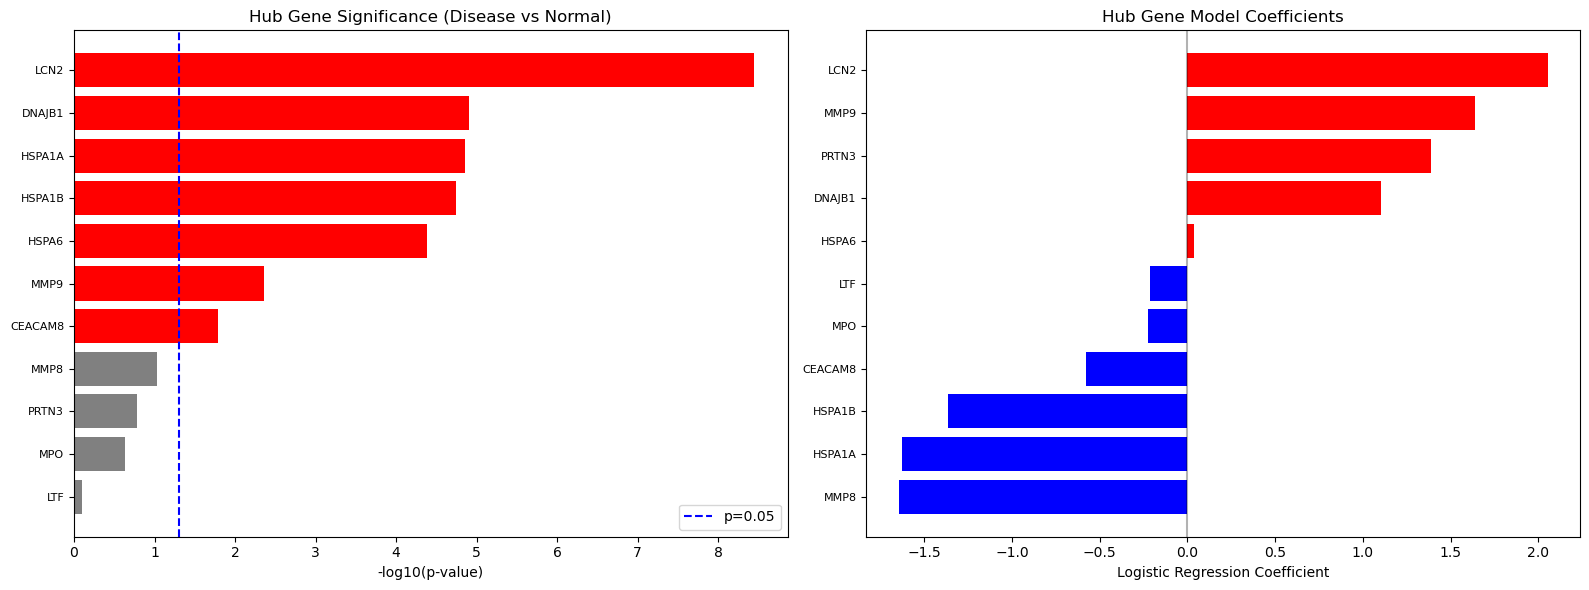

In [33]:
# --- Visualize feature importance ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_feat = feature_importance.head(20)
colors_pval = ['red' if p < 0.05 else 'gray' for p in top_feat['p_value']]
axes[0].barh(range(len(top_feat)), top_feat['neg_log10_p'].values, color=colors_pval)
axes[0].set_yticks(range(len(top_feat)))
axes[0].set_yticklabels(top_feat['gene'].values, fontsize=8)
axes[0].set_xlabel('-log10(p-value)')
axes[0].set_title('Hub Gene Significance (Disease vs Normal)')
axes[0].axvline(x=-np.log10(0.05), color='blue', linestyle='--', label='p=0.05')
axes[0].legend()
axes[0].invert_yaxis()

if 'coefficient' in feature_importance.columns:
    top_feat_sorted = feature_importance.head(20).sort_values('coefficient')
    colors_coef = ['red' if c > 0 else 'blue' for c in top_feat_sorted['coefficient']]
    axes[1].barh(range(len(top_feat_sorted)), top_feat_sorted['coefficient'].values, color=colors_coef)
    axes[1].set_yticks(range(len(top_feat_sorted)))
    axes[1].set_yticklabels(top_feat_sorted['gene'].values, fontsize=8)
    axes[1].set_xlabel(f'{best_model_name} Coefficient')
    axes[1].set_title('Hub Gene Model Coefficients')
    axes[1].axvline(x=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# --- Final Summary ---
print("=" * 70)
print("LIVER CANCER GENE EXPRESSION ANALYSIS - SUMMARY")
print("=" * 70)
print(f"\nDataset: GSE263786")
print(f"Samples: {df.shape[1]} (Disease: {(y==1).sum()}, Normal: {(y==0).sum()})")
print(f"Total genes: {df.shape[0]}")
print(f"Genes after filtering: {df_filtered.shape[0]}")
print(f"Genes selected by PCA: {df_selected.shape[0]}")
print(f"\nPCA components for 90% variance: {n_components_90}")
print(f"K-means gene clusters: {optimal_k}")
print(f"\nPPI Network (prebuilt M_PPI): {ppi_graph.number_of_nodes()} nodes, {ppi_graph.number_of_edges()} edges")
print(f"GRN Network (prebuilt M_GRN): {grn_graph.number_of_nodes()} nodes, {grn_graph.number_of_edges()} edges")
print(f"GRN modules: {n_modules} (disease-significant: {len(sig_modules)})")
print(f"\nHub genes identified: {len(hub_genes)}")
print(f"Hub genes used as classifier features: {len(feature_names)}")
print(f"\nClassifier: {best_model_name}")
print(f"  CV Accuracy (LDA):     {lda_scores.mean():.4f} +/- {lda_scores.std():.4f}")
print(f"  CV Accuracy (LogReg):  {lr_scores.mean():.4f} +/- {lr_scores.std():.4f}")
print(f"  AUC:                   {auc:.4f}")
print(f"  Significant features:  {feature_importance['significant'].sum()} / {len(feature_importance)}")
print(f"\nTop 10 Hub Genes for Liver Cancer Diagnosis:")
for _, row in feature_importance.head(10).iterrows():
    tags = []
    if row['is_TF']:
        tags.append('TF')
    if row['is_Receptor']:
        tags.append('Receptor')
    tag_str = f" [{','.join(tags)}]" if tags else ""
    print(f"  {row['gene']:<14} p={row['p_value']:.2e}{tag_str}")
print("=" * 70)
